<a href="https://colab.research.google.com/github/shuvamadhikary6388-lang/ML/blob/main/Self_explanatory_Clustering_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Welcome to my clustering Notebook. Everything here is self explanatory**



---


**K-MEANS CLUSTERING**


---


1. K-Means is a centroid-based clustering algorithm used to
partition a dataset into K distinct clusters.
2. The algorithm begins by randomly initializing K centroids in the dataset.
3. Each data point is assigned to the nearest centroid using Euclidean distance.
4. After assignment, the centroid of each cluster is recomputed as the mean of all points in that cluster.
5. The assignment and centroid update steps repeat until convergence or no change in cluster membership.
6. K-Means tries to minimize the within-cluster sum of squared distances (WCSS).
7. The value of K must be chosen beforehand, often using the Elbow Method or Silhouette Score.
8. It works best when clusters are spherical and similar in size, but it is sensitive to outliers.


---



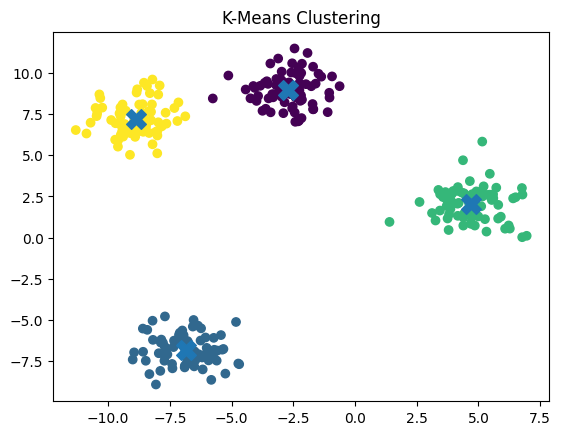

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate dataset
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Model
kmeans = KMeans(n_clusters=4, random_state=42)

# Train
kmeans.fit(X)

# Predict clusters
labels = kmeans.predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.title("K-Means Clustering")
plt.show()



---


**K-MEDIAN CLUSTERING**


---


1. K-Median clustering is similar to K-Means but uses the median instead of the mean to define cluster centers.

2. The algorithm partitions data into K clusters based on distance to the nearest cluster center.

3. Each cluster center is calculated as the median of the data points in that cluster.

4. It generally uses Manhattan distance (L1 norm) rather than Euclidean distance.

5. The algorithm iteratively assigns points to clusters and updates the median centers.

6. It is more robust to outliers compared to K-Means because the median is less affected by extreme values.

7. The number of clusters K must be specified before training.

8. K-Median is useful in datasets where noise and extreme values are present.


---



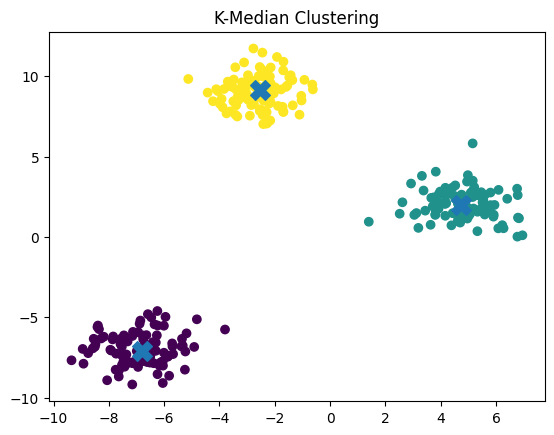

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate dataset
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

# Parameters
k = 3
max_iter = 100

# Random initialization
centroids = X[np.random.choice(len(X), k, replace=False)]

for _ in range(max_iter):

    # Compute distances
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

    # Assign clusters
    labels = np.argmin(distances, axis=1)

    new_centroids = []

    # Update centroids using median
    for i in range(k):
        cluster_points = X[labels == i]
        new_centroids.append(np.median(cluster_points, axis=0))

    new_centroids = np.array(new_centroids)

    # Stop if converged
    if np.all(centroids == new_centroids):
        break

    centroids = new_centroids

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title("K-Median Clustering")
plt.show()



---


**K-MEDOIDS CLUSTERING**


---


1. K-Medoids is a partitioning clustering algorithm closely related to K-Means.

2. Instead of using the mean or median, the cluster center is an actual data point (medoid).

3. A medoid is the point whose average distance to all other points in the cluster is minimal.

4. The algorithm assigns points to the nearest medoid using a distance metric.

5. It iteratively swaps medoids with non-medoid points to minimize clustering cost.

6. The most common algorithm for K-Medoids is PAM (Partitioning Around Medoids).

7. It is more robust to noise and outliers than K-Means.

8. However, K-Medoids is computationally more expensive, especially for large datasets.


---



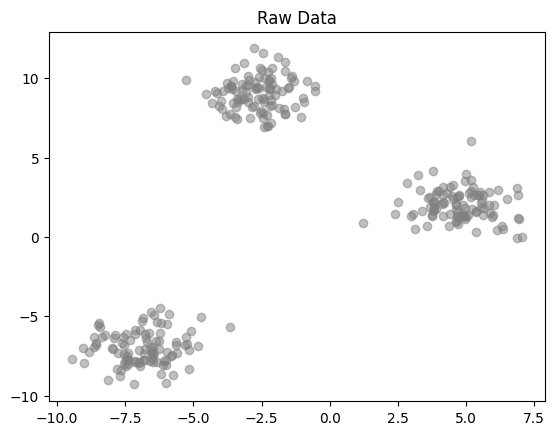

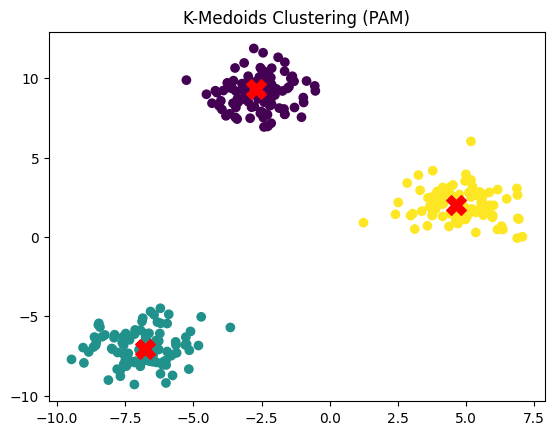

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate dataset
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.05, random_state=42)

# Plot raw data
plt.scatter(X[:,0], X[:,1], c='gray', alpha=0.5)
plt.title("Raw Data")
plt.show()


# Number of clusters
k = 3

# Randomly choose medoids
np.random.seed(42)
medoid_indices = np.random.choice(len(X), k, replace=False)
medoids = X[medoid_indices]

for _ in range(100):

    # Compute distances to medoids
    distances = np.linalg.norm(X[:, None] - medoids, axis=2)

    # Assign clusters
    labels = np.argmin(distances, axis=1)

    new_medoids = []

    for i in range(k):
        cluster_points = X[labels == i]

        # Compute distance matrix
        dist_matrix = np.sum(
            np.linalg.norm(cluster_points[:, None] - cluster_points, axis=2),
            axis=1
        )

        # Choose point with minimum distance
        new_medoid = cluster_points[np.argmin(dist_matrix)]
        new_medoids.append(new_medoid)

    new_medoids = np.array(new_medoids)

    # Stop if no change
    if np.all(medoids == new_medoids):
        break

    medoids = new_medoids


# Plot clusters
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(medoids[:,0], medoids[:,1], c='red', marker='X', s=200)
plt.title("K-Medoids Clustering (PAM)")
plt.show()



---


**AGGLOMERATIVE CLUSTERING**


---



1. Agglomerative clustering is a hierarchical clustering technique based on a bottom-up approach.

2. Initially, each data point is considered as its own cluster.

3. The algorithm repeatedly merges the two closest clusters at each step.

4. Cluster similarity is measured using linkage criteria such as single, complete, average, or Ward linkage.

5. The process continues until all points are merged into one cluster or a stopping condition is reached.

6. The result is represented using a dendrogram, which shows hierarchical relationships between clusters.

7. The number of clusters can be determined by cutting the dendrogram at a certain level.

8. Hierarchical clustering does not require specifying the number of clusters initially, but it is computationally expensive for large datasets.


---



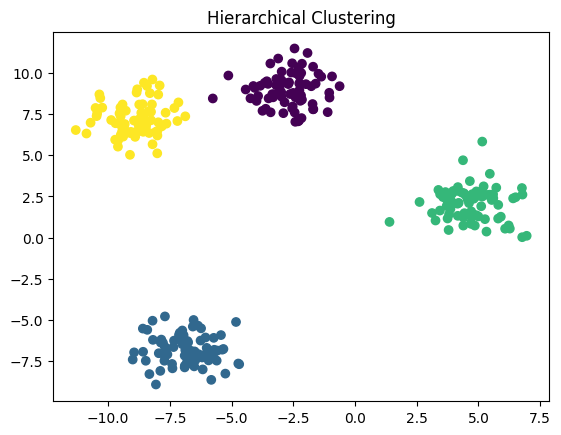

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

# Dataset
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Model
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Fit
labels = hc.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Hierarchical Clustering")
plt.show()



---


DBSCAN (Density-Based Spatial Clustering of Applications with Noise)


---


1. DBSCAN is a density-based clustering algorithm that groups points based on density.

2. It identifies clusters as regions with high point density separated by low-density areas.

3. The algorithm requires two parameters: epsilon (ε) and minimum number of points (minPts).

4. Points are categorized into core points, border points, and noise points.

5. A core point has at least minPts points within distance ε.

6. Clusters are formed by expanding from core points to their density-connected neighbors.

7. DBSCAN can discover clusters of arbitrary shapes, unlike K-Means.

8. It also automatically detects outliers as noise points.


---



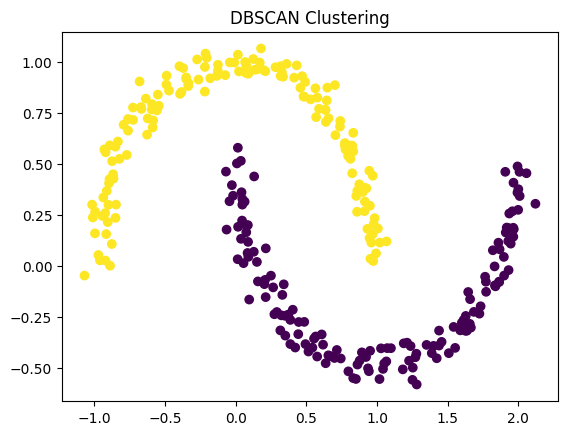

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Dataset
X, y = make_moons(n_samples=300, noise=0.05)

# Model
dbscan = DBSCAN(eps=0.2, min_samples=5)

# Fit
labels = dbscan.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN Clustering")
plt.show()



---


**MEAN SHIFT CLUSTERING **


---


1. Mean Shift is a centroid-based clustering algorithm used to identify clusters in a dataset.

2. It works by iteratively shifting data points toward regions of higher data density.

3. Each point moves toward the mean of points within its neighborhood (kernel window).

4. The window size is controlled by a parameter called bandwidth.

5. Points that converge to the same region are grouped into the same cluster.

6. Unlike K-Means, Mean Shift does not require specifying the number of clusters beforehand.

7. It can detect clusters of arbitrary shapes and automatically determine cluster centers.

8. However, Mean Shift can be computationally expensive for large datasets.


---



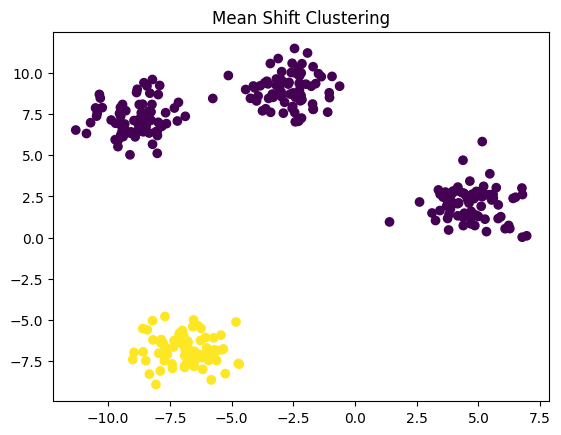

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift
from sklearn.datasets import make_blobs

# Dataset
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Model
meanshift = MeanShift()

# Fit
labels = meanshift.fit_predict(X)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Mean Shift Clustering")
plt.show()